In [2]:

def load_model_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_sum.pt"))

def load_R2SP_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "R2SP_client_sum.pt"))

def load_server_to_client_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "sever_to_client_sum.pt"))

def load_client_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_loss.pt"))

def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        print(c[0] == 0)
        return c[1:]
    else:
        return c

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))


def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))

def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))        

def get_acc_time(acc,time):
    target_acc = [0.59]
    n = 10
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*4
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = cv_time[index]
                ac_time[i] = cv_time[index]
                i = i+1
    return ac_time



# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"
    

           
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

dataset_name = "ImageNet100"
import configs.imagenet100 as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 10



result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 5, 1, 5)), (0, (1, 10))]
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
markers = ['o', '*', 'D', 's', 'p', 'v', '^', 'x', 'h', 'H', '<', '>', 'd', '+', '1', '2', '3', '4']

In [3]:
result_path = join("results", config.EXP_NAME,'Best_ratio2')
import os
list2 = os.listdir(result_path)
list2 = sorted(list2)
list2

['PMT0.05',
 'PMT0.1',
 'PMT0.2',
 'PMT0.4',
 'PMT0.6',
 'PMT0.7',
 'PMT0.8',
 'PMT0.9',
 'PMT1.0']

Skipping training results for ImageNet100, PMT0.1. Client selection = False.
Skipping training results for ImageNet100, PMT0.2. Client selection = False.


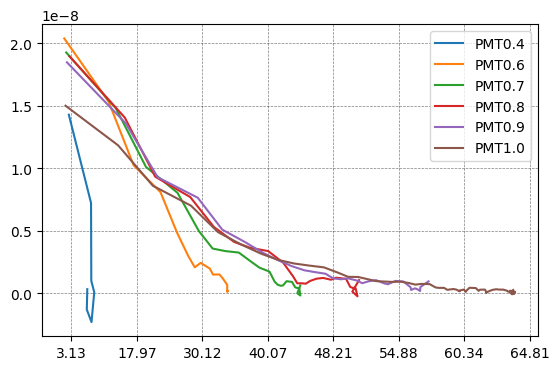

In [25]:
plt.figure()
list2 = ['PMT0.1',
 'PMT0.2',
 'PMT0.4',
 'PMT0.6',
 'PMT0.7',
 'PMT0.8',
 'PMT0.9',
 'PMT1.0']

import numpy as n
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import torch
def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def conv(acc, n):
    new_acc = []
    n = int(n/2)
    if n > len(acc):
        print('list is too short')
    for i in range(len(acc)):
        if i == 0 or i == len(acc)-1:
            new_acc.append(acc[i])
        else:
            windows = min(i,n,len(acc)-1-i)
            new_acc.append(np.mean(acc[i-windows:i+windows+1]))
    new_acc = np.array(new_acc)
    return new_acc
                    
                           
full_time = load(join(result_path, "{}".format('PMT1.0'), "est_time.pt"))[0]          
n=5
interval = 2
final_density = 0.85
acc_list = []
time_list = []
label_list = []
for i in range(len(list2)):
    exp_name = list2[i]
    try:
        acc = load_fed_avg_acc(exp_name)
        time = load_real_time(exp_name)
        time = np.linspace(0, time[-1].cpu(), len(acc) )
        time = list(time)
        # if len(acc) < 5:
        #     continue
        acc = conv(acc, n)
        
        time2 = load(join(result_path, "{}".format(exp_name), "est_time.pt"))
        
        import re
        ratio = full_time * 0.05 + 0.95 * full_time * float(re.findall(r'\d+\.?\d*', exp_name)[0])
        ratio = float(ratio)
        
        time =  np.array([t*ratio for t in time])
        

        growth_rate_smooth = np.gradient(acc, time)

        # === 可选：以准确率为横轴重建关系 ===
        # 注意 acc_dense 单调时才可以这么做，否则要做处理
        log_acc = -np.log(final_density-acc)


        plt.plot(log_acc, growth_rate_smooth,  label=exp_name, )
        acc_list.append(log_acc),time_list.append(growth_rate_smooth), label_list.append(exp_name)

    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")


# plt.xlim([-0.0000025,1e5])
# plt.xlabel('accuracy', fontsize=21)
# plt.ylabel("growth_rate", fontsize=21)
# plt.legend(list2,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(True)  # Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
def format_kilo3(x, _):
    return f"{((final_density - np.exp(-x))*100):.2f}"
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo3))
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def linear_between_neighbors(x_raw, y_raw, x_target):
    x_raw = np.asarray(x_raw)
    y_raw = np.asarray(y_raw)
    sort_idx = np.argsort(x_raw)
    x_sorted = x_raw[sort_idx]
    y_sorted = y_raw[sort_idx]
    result = np.full_like(x_target, np.nan, dtype=np.float64)
    for i, xt in enumerate(x_target):
        idx = np.searchsorted(x_sorted, xt)
        if 0 < idx < len(x_sorted):
            x0, x1 = x_sorted[idx - 1], x_sorted[idx]
            y0, y1 = y_sorted[idx - 1], y_sorted[idx]
            t = (xt - x0) / (x1 - x0)
            result[i] = (1 - t) * y0 + t * y1
        else:
            result[i] = -5e-9
    return result
    
def plot_max_segment_lines(x_list, y_list, label_list):
    num_lines = len(x_list)

    # 统一采样 x
    xmin = max([min(x) for x in x_list])
    xmax = max([max(x) for x in x_list])
    t = np.linspace(0, 1, 300)
    x_uniform = xmin + (xmax - xmin) * t**1.5 

    # 插值
    y_interp_all = []
    for xk, yk in zip(x_list, y_list):
        y_interp = linear_between_neighbors(xk, yk, x_uniform)
        y_interp_all.append(y_interp)
    y_interp_all = np.array(y_interp_all)  # shape: (num_lines, len(x_uniform))

    # 准备颜色
    colors = plt.cm.tab10(np.linspace(0, 1, num_lines))

    fig, ax = plt.subplots()
    # 分段画图
    for i in range(len(x_uniform) - 1):
        x_seg = [x_uniform[i], x_uniform[i+1]]
    
        y_start = y_interp_all[:, i]
        y_end = y_interp_all[:, i+1]
    
        # 对这一段的平均 y 排序（更稳）
        y_avg = (y_start + y_end) / 2
        if np.all(np.isnan(y_avg)):
            continue
    
        max_idx = np.nanargmax(y_avg)
    
        for k in range(num_lines):
            y_seg = [y_interp_all[k, i], y_interp_all[k, i+1]]
            if np.any(np.isnan(y_seg)):
                continue

            linestyle = '-'
            ax.plot(x_seg, y_seg, color=colors[k], linestyle=linestyle, linewidth=1.5)



    # 添加自定义图例（因为每条线是分段绘制的，正常 plot 无法生成完整图例）
    legend_lines = [
        Line2D([0], [0], color=colors[k], linestyle='-', linewidth=2, label=label_list[k])
        for k in range(num_lines)
    ]
    ax.legend(handles=legend_lines)  
    
    ax.set_xlabel("growth rate")
    ax.set_ylabel("accuracy")
    def format_kilo3(x, _):
        return f"{((final_density - np.exp(-x))*100):.2f}"
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo3))
    # ax.set_title("Only Max Line is Solid Per Segment")
    plt.grid(True)
    plt.show()


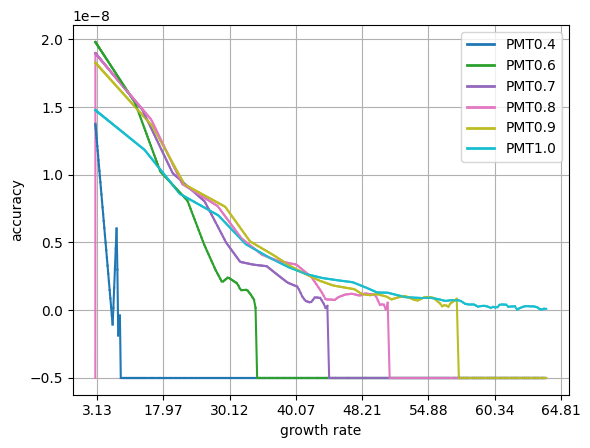

In [31]:
x_list = acc_list
y_list = time_list
label_list
plot_max_segment_lines(x_list, y_list, label_list)

In [28]:
import os
list = os.listdir(result_path)
list = sorted(list)
list

['.ipynb_checkpoints',
 'Ablation_iid_high__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_iid_low__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_iid_medium__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_iid_medium__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_iid_medium__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_iid_medium__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.

In [29]:
#GMR on client heterogeneity

In [26]:
def get_time_acc(acc,time,time_line):
    windows = 5
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)


    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100
    f_mean = np.mean(acc[-1-windows:-1])*100
    f_std = np.std(acc[-1-windows:-1])*100

    cv_acc = np.convolve(acc, np.ones((windows,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((windows,)) / n, mode='valid')

    for t,a in zip(cv_time,cv_acc):
        if a >= f_mean:
            break
                    

    return [round(b_mean, 2),f"{b_std:.2g}",t]

def plt_time_acc(exp, time_line):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            time = load_time(exp_name)
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    for key in time_acc.keys():
        print(f"{key}: {time_acc[key]}")

In [31]:
exp2 = [

 'niid_medium__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
     'niid_medium__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
]
plt_time_acc(exp2,120000)

niid_medium__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50: [30.05, '5.4', 1384421.8178268736]
niid_medium__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50: [53.47, '0.61', 272323.31067787885]
niid_medium__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50: [53.83, '0.67', 255555.3700057054]
niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50: [56.54, '0.98', 177353.1775001903]


In [32]:
#with BaseLine

True
True
True
True
PR-FL : [127175.44835511253, None, None, None]
Syn-FL : [637188.2904136864, None, None, None]
Asyn-FL : [137736.33133795054, None, None, None]
Sub_FL : [267544.1606322295, None, None, None]


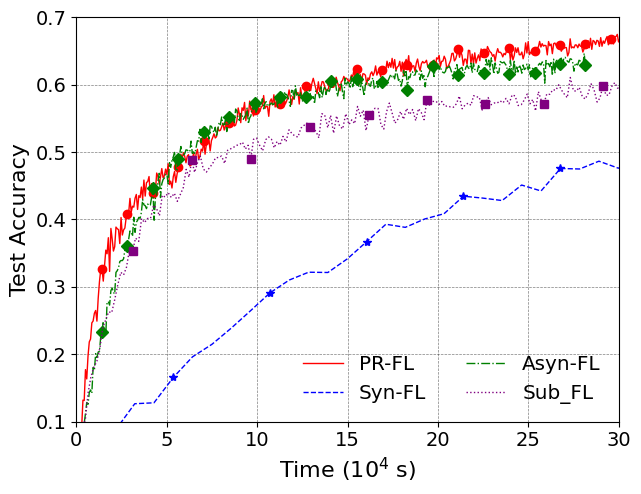

True
True
True
True
PR-FL : [144780.5198681284, None, None, None]
Syn-FL : [637124.206565306, None, None, None]
Asyn-FL : [220000.8166294058, None, None, None]
Sub_FL : [256252.57132260484, None, None, None]


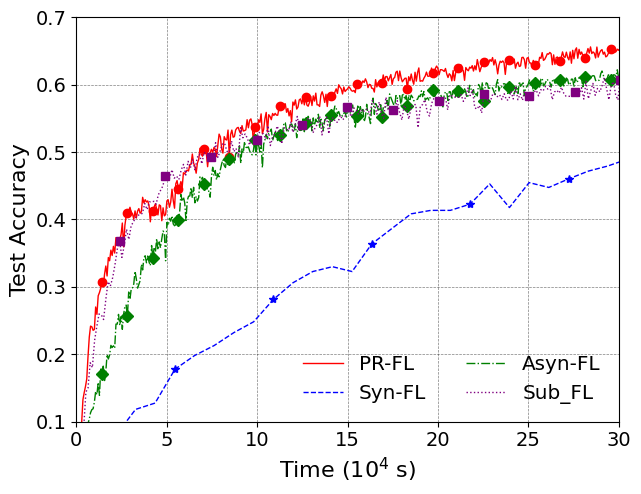

True
True
True
True
PR-FL : [177137.00641306376, None, None, None]
Syn-FL : [674179.9128628974, None, None, None]
Asyn-FL : [None, None, None, None]
Sub_FL : [265963.7192918852, None, None, None]


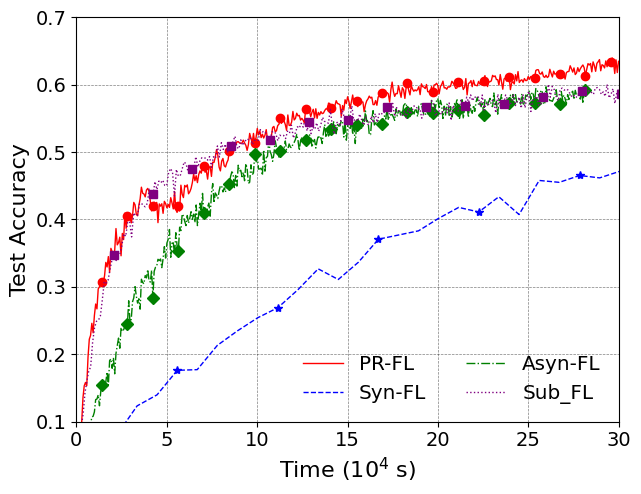

In [43]:


exp1 = [

 'niid_low__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
'niid_low__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 # 'niid_low__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

]


exp_legend = [   
     # 'patience_10,PR-FL',
    'PR-FL',
    'Syn-FL',
    'Asyn-FL',
    # 'Sub-FL',
    'Sub_FL'
]





exp2 = [
 'niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
     'niid_medium__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'niid_medium__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',


]

exp3 = [
 'niid_high__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'niid_high__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
]


fig_name_list = ['Tiny_low_niid','Tiny_medium_niid','Tiny_high_niid']
exp_list = [exp1,exp2,exp3]
for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.1,0.7],x_lim= [0,300000])
    # plt_time_acc(exp,250000)
    


In [29]:
# With IID

True
True
True
True
PR-FL : [125804.35225086812, None, None, None]
FedAvg : [528236.9364427357, None, None, None]
FedAsyn : [163060.59356661004, None, None, None]
HeteroFL : [199050.2300356073, None, None, None]


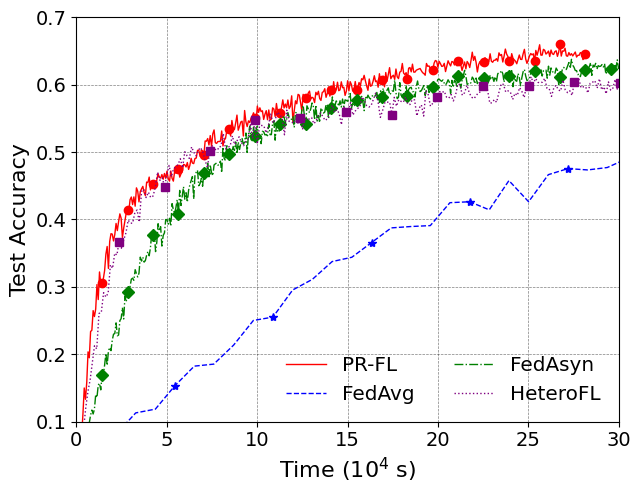

In [36]:
exp1 = [
    # 'patience10niidlow_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_Cifar10_[1, 0.5, 0.2, 0.1, 0.05]_poly_50',

 'iid_low__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
     'iid_low__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'iid_low__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'iid_low__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
]


exp_legend = [   
     # 'patience_10,PR-FL',
    'PR-FL',

    'FedAvg',
        'FedAsyn',
    'HeteroFL',
]

exp2 = [
 'iid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
     'iid_medium__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'iid_medium__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'iid_medium__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
]

exp3 = [
 'iid_high__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
     'iid_high__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'iid_high__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'iid_high__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
]

fig_name_list = ['medium_iid']
exp_list = [exp2]
for i in range(len(exp_list)):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.70],x_lim= [0,300000])

In [56]:
#patience with GMR

In [ ]:
 'niid_medium__1.0_10_fed_asyn_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_fed_avg_ImageNet100_15.0_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_heterofl_ImageNet100_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_heterofl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

 'niid_medium__1.0_10_pr_fl_ImageNet100_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_1_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_3_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_7_[1.0, 0.5, 0.2, 0.1, 0.05]__50'

True
True
True
True
patience_1 : [231269.60565901297, None, None, None]
patience_5 : [144780.5198681284, None, None, None]
patience_10 : [190490.09401136602, None, None, None]
patience_20 : [201005.2006454267, None, None, None]


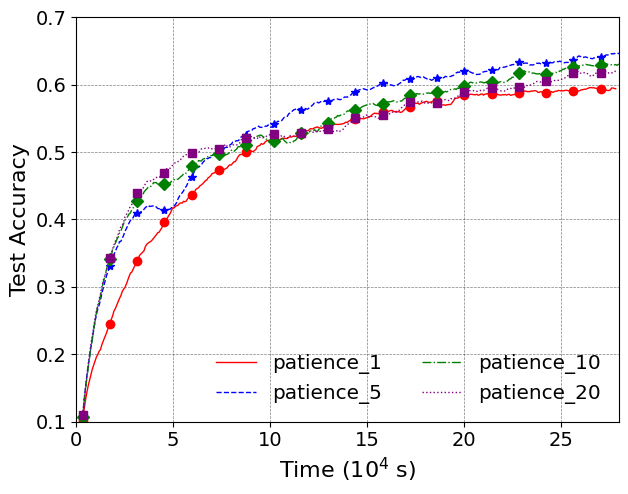

In [47]:



exp1 = [

'niid_low__1.0_10_pr_fl_ImageNet100_1_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_ImageNet100_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_ImageNet100_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_low__1.0_10_pr_fl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',


]

exp_legend = [   
        'patience_1',
        'patience_5',
        'patience_10',
        # 'patience_15',
        'patience_20',

]

exp2 = [
'niid_medium__1.0_10_pr_fl_ImageNet100_1_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 # 'niid_medium__1.0_10_pr_fl_ImageNet100_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_medium__1.0_10_pr_fl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',



]


exp3 = [

'niid_high__1.0_10_pr_fl_ImageNet100_1_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_pr_fl_ImageNet100_10_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_pr_fl_ImageNet100_15_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'niid_high__1.0_10_pr_fl_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',


]


fig_name_list = ['patience']
exp_list = [exp2]

for i in range(len(exp_list)):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.1,0.70],x_lim= [0,280000], cov = True)



In [ ]:

 'Ablation_niid_high__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_high__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

In [59]:
# Ablation Experiment

True
True
True
True
True
PR-FL : [141963.64125698232, 209453.15775313764, None, None]
-GMR : [260813.87664461625, None, None, None]
-Asyn : [511708.0808826277, 962451.7876908642, None, None]
-Buff : [144780.5198681284, 259404.72524835452, None, None]
-maskfedavg : [139850.24036939396, 254473.1365958836, None, None]


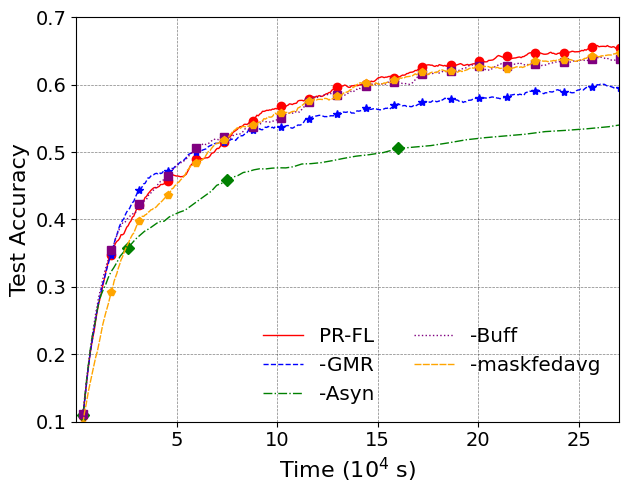

True
True
True
True
True
PR-FL : [156730.40736067746, 258699.36135188738, None, None]
-GMR : [288248.6869329792, None, None, None]
-Asyn : [615990.3837836582, 1117400.8887158628, None, None]
-Buff : [212267.63093393607, None, None, None]
-maskfedavg : [162359.27166561503, 259404.72524835452, None, None]


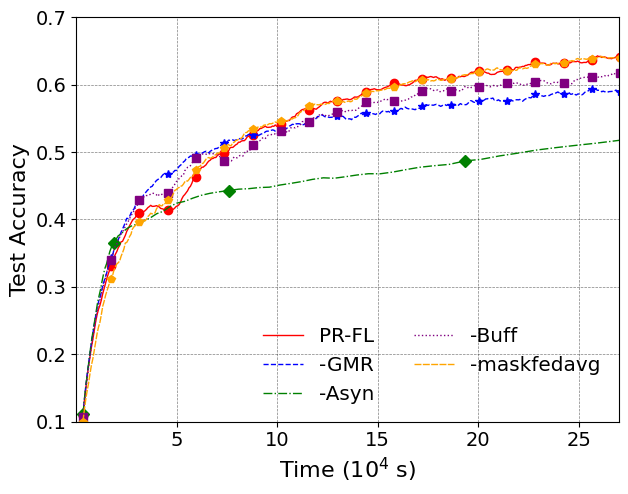

True
True
True
True
PR-FL : [217897.69406409975, None, None, None]
-GMR : [None, None, None, None]
-Asyn : [729901.7277408689, 1209326.2549582429, None, None]
-Buff : [None, None, None, None]


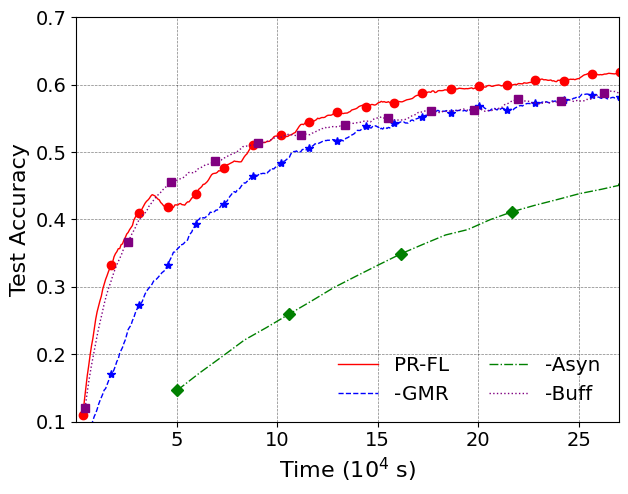

In [12]:
exp1 = [
'niid_low__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50', 
'Ablation_niid_low__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

'Ablation_niid_low__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_low__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
    ]

exp2 = [
'niid_medium__1.0_10_pr_fl_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
'Ablation_niid_medium__1.0_10_gmr_ImageNet100_20_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_asyn_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_buff_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',
 'Ablation_niid_medium__1.0_10_mask_fed_avg_ImageNet100_5_[1.0, 0.5, 0.2, 0.1, 0.05]__50',

]



exp_legend = [    
    'PR-FL',   
        '-GMR',
        '-Asyn',
         '-Buff',
        '-maskfedavg',
]


fig_name_list = ['Tiny_low_Ablation','Tiny_medium_Ablation','Tiny_high_Ablation']

exp_list = [exp1,exp2,exp3]
for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.70], x_lim=[1, 270000], cov = True)

    



Skipping high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25. Client selection = False.
Skipping high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25. Client selection = False.


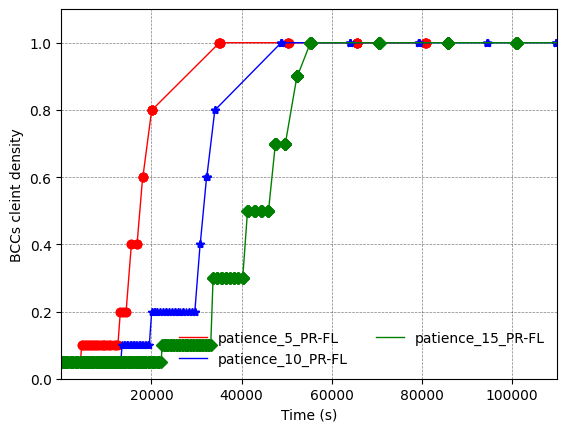

In [89]:
exp1 = [
     'niid_high__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
 'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
]



exp_legend = [   
         'patience_5_PR-FL',
     'patience_10_PR-FL',
     'patience_15_PR-FL',

    'FedAsyn',
    'HeteroFL',
]

# exp2 = [
# 'patience10medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25']

# exp3 = [
#     'patience10high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',]

for exp in[exp1]:
    plt_photo_density(exp,exp_legend,y_lim=[0,1.1])

1


/tmp/ipykernel_593255/3733655727.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


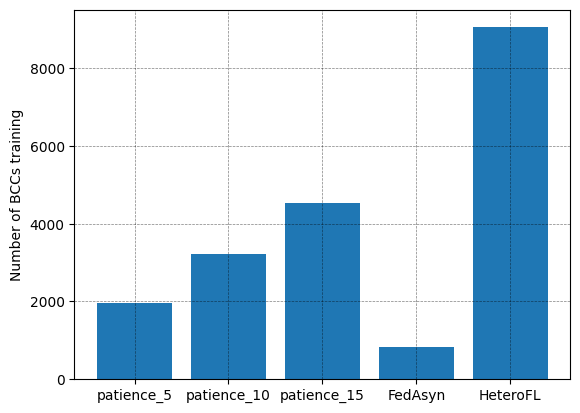

In [95]:
exp1 = [
     'niid_high__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
 'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
]



exp_legend = [   
         'patience_5',
     'patience_10',
     'patience_15',

    'FedAsyn',
    'HeteroFL',
]

# exp2 = [
# 'patience10medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25']

# exp3 = [
#     'patience10high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',]

for exp in[exp1]:
    print('1')
    plt_photo_client_train_number(exp,exp_legend)

True
True


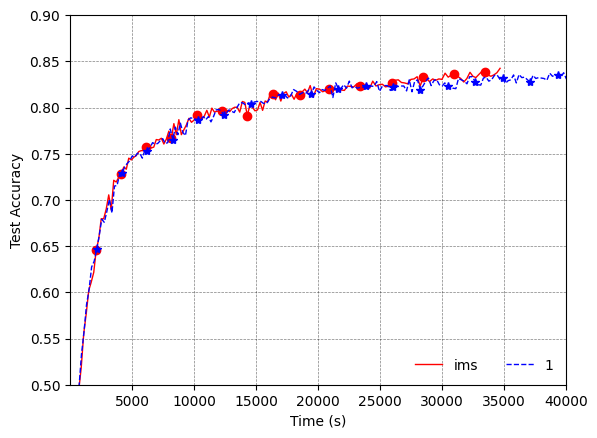

True
0
True
1


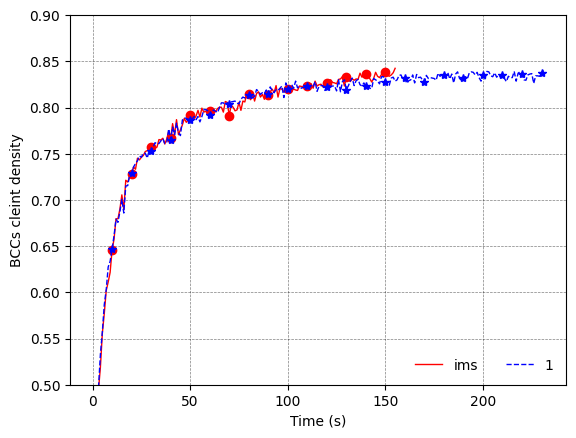

In [35]:

 # '2Ablation_niid_medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niid_medium__1.0_10_mask_fed_avg_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu2.5__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu2.5__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu20.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu20.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu40.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu40.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu5.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu50.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',


#old setting, set every client at fixed interval
exp1 = [
 '3Ablation_niid_medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__250.5',


 '3Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__251.0',
 # '3Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__252.0',
 # '3Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__254.0',
 # '3Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__250.1',
 # '3Ablation_niid_medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__250.5',

]



exp_legend = [   
    'ims',
         '1',
     '2',
     '4',

    '0.1',
    '0.5',
]


for exp in[exp1]:
    plt_photo_acc(exp,exp_legend,y_lim=[0.5,0.9],x_lim=[1, 40000])
for exp in[exp1]:
    plt_photo_round_acc(exp,exp_legend,y_lim=[0.5,0.9])

True
True


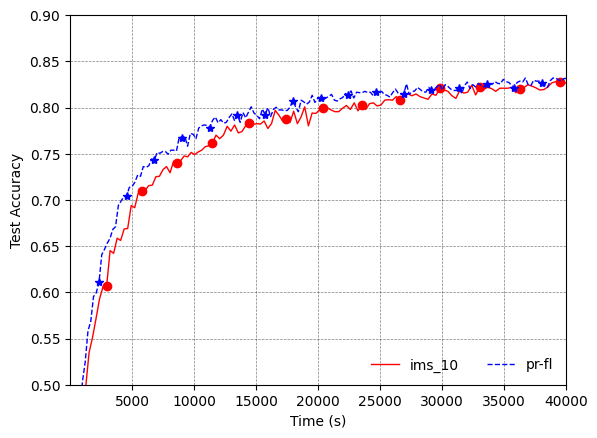

True
True


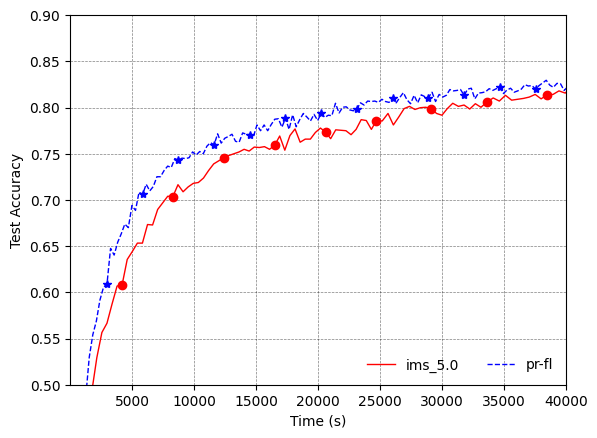

True
True


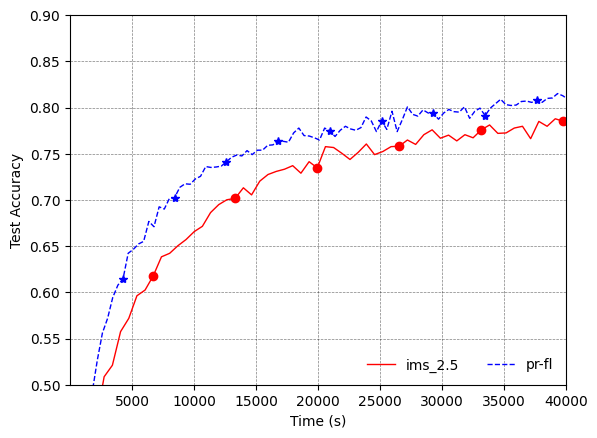

True
True


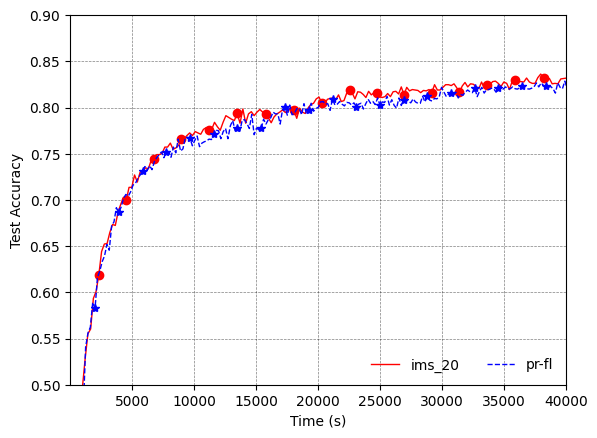

True
True


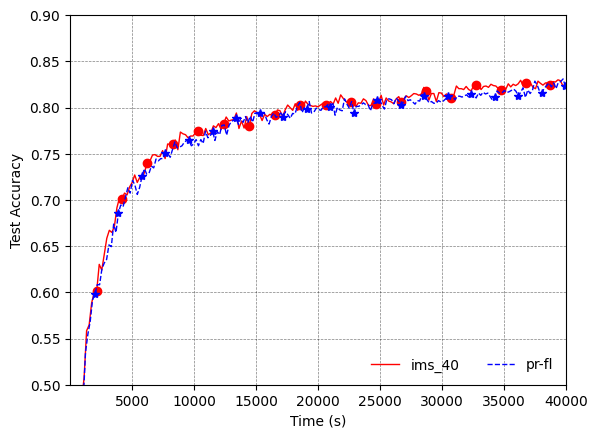

In [20]:



#new setting, set every client at fixed interval

exp1 = [

 'Ablation_niid_medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',


]



exp_legend1 = [   
    'ims_10',
    'pr-fl',

]

exp2 = [


 'Ablation_niidsu5.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niidsu5.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',

]



exp_legend2 = [   

    'ims_5.0',
    'pr-fl',
]

exp3 = [


 'Ablation_niidsu2.5__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niidsu2.5__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',


]



exp_legend3 = [   

    'ims_2.5',
    'pr-fl',

]
exp4 = [


 'Ablation_niidsu20.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niidsu20.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu40.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu40.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu5.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 # '2Ablation_niidsu5.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',

]



exp_legend4 = [   

    'ims_20',
    'pr-fl',

]
exp5 = [


 'Ablation_niidsu40.0__medium__1.0_10_ims_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niidsu40.0__medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',


]



exp_legend5 = [   

        'ims_40',
    'pr-fl',

]




exp = [exp1,exp2,exp3,exp4,exp5]
exp_legend = [exp_legend1,exp_legend2,exp_legend3,exp_legend4,exp_legend5]
figname = ['ims10','ims5','ims2.5','ims20','ims40']
for ex,el,fn in zip(exp,exp_legend,figname):
    plt_photo_acc(ex,el,fig_name = fn,y_lim=[0.5,0.9],x_lim=[1, 40000])


0
1
2
3
4


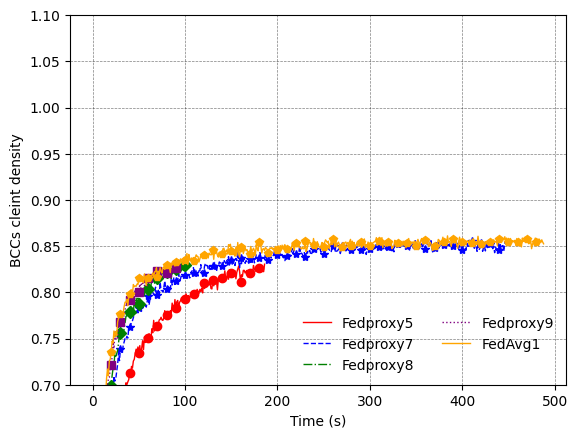

results/FEMNIST/PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__recover_polybuff_mask_fed_avg_Resdiual_niid__n__25_0.1____esc/self.time
335 335
results/FEMNIST/PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__polybuff_mask_fed_avg_Resdiual_niid__n__25_0.1____esc/self.time
344 344
results/FEMNIST/PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__polybuff_fed_avg_Resdiual_niid__n__25_0.1____esc/self.time
277 277
results/FEMNIST/PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__recover_polymask_fed_avg_Resdiual_niid__n__25_0.1____esc/self.time
345 345


<Figure size 640x480 with 0 Axes>

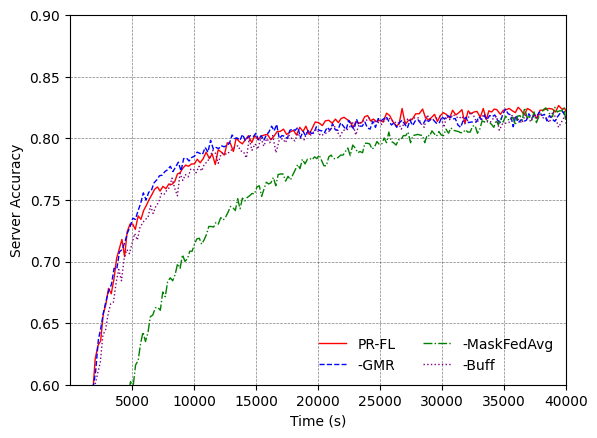

In [6]:
import matplotlib.pyplot as plt
import os
from os.path import join

# 创建一个新的 figure
plt.figure()

# 遍历所有实验，绘制每个实验的曲线
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        # 加载数据
        avg_acc = load_acc(exp_name)
        fed_avg_acc = load_fed_avg_acc(exp_name)
        time = load_time(exp_name)

        print(len(time), len(avg_acc))

        # 绘制曲线
        plt.plot(time, avg_acc,linestyle=linestyles[i%4],color = colors[i],linewidth=1, label=exp_legend[i])

    except FileNotFoundError:
        print(f"Skipping {exp_name}. Client selection = {client_sel}.")

# 设置标签和坐标轴范围
plt.xlabel("Time (s)")
plt.ylabel("Test Accuracy")
plt.xlim([1, 40000])
plt.ylim([0.60, 0.90])

# 添加图例
plt.legend(
    exp_legend,
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(1, 0),  # 图例放置在右下角
    fontsize='medium',
    ncol=2  # 图例按 3 列排列
)

# 设置网格
plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

# 显示图像
plt.show()

# 保存图像
result_path = join("results", config.EXP_NAME)
fig_path = join(result_path, "figs")

if not os.path.isdir(fig_path):
    os.makedirs(fig_path)

plt.savefig(join(fig_path, "FR-FL.png"), dpi=300)  # 保存为 PNG 格式


In [45]:
exp = [
      
    'PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__recover_polybuff_mask_fed_avg_Resdiual_niid__n__25_0.1____esc',
    'PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]1.0__recover_polyfed_avg_Resdiual_niid__n__25_0.1____esc',
    'PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]1.0__asyn__recover_polyfedasyn_Resdiual_niid__n__25_0.1____esc',
    'PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__polyheterofl_niid__n__25_0.1____esc',

]


In [63]:
checkpoint = load(os.path.join(result_path+'/PR_FEMNIST2_[1.0, 0.5, 0.1, 0.05]0.02__asyn__recover_polybuff_mask_fed_avg_Resdiual_niid__n__25_0.1____esc', 'checkpoint.pth'))

for var_name, value in checkpoint.items():
    if var_name.startswith('self.'):
        var_name = var_name[5:]  # 去除 'self.' 前缀
        


model
list_client_sd
control.accumulate_weight_dict
list_mask
list_stalness
list_coeff


In [ ]:
plt.figure()

for i in range(len(exp)):
    exp_name = exp[i]
    try:
        client_sum = load_model_sum(exp_name)
        client_sum = [[s.cpu().numpy() for s in cs] for cs in client_sum]

        client_acc = np.array(client_sum) 

        for col in range(0,10,4):
            plt.plot(client_acc[:, col], label='c_s_'+str(exp_legend[i])+f'Column {col+1}')
    
    
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")

plt.xlabel(r"Round (s)")
plt.ylabel("Client sum")

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


<IPython.core.display.Javascript object>

In [55]:
exp = [ 'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_fed_avg_g_0.0_0.0',
       'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_30_no_increase_-1.0_sub_fed_avg_g_0.0_0.0',
       'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_R2SP_g_0.0_0.0',
       

      
      ]
exp_legend = [ 'fed_avg',
             'sub_fed_avg',
             'R2SP']


<IPython.core.display.Javascript object>


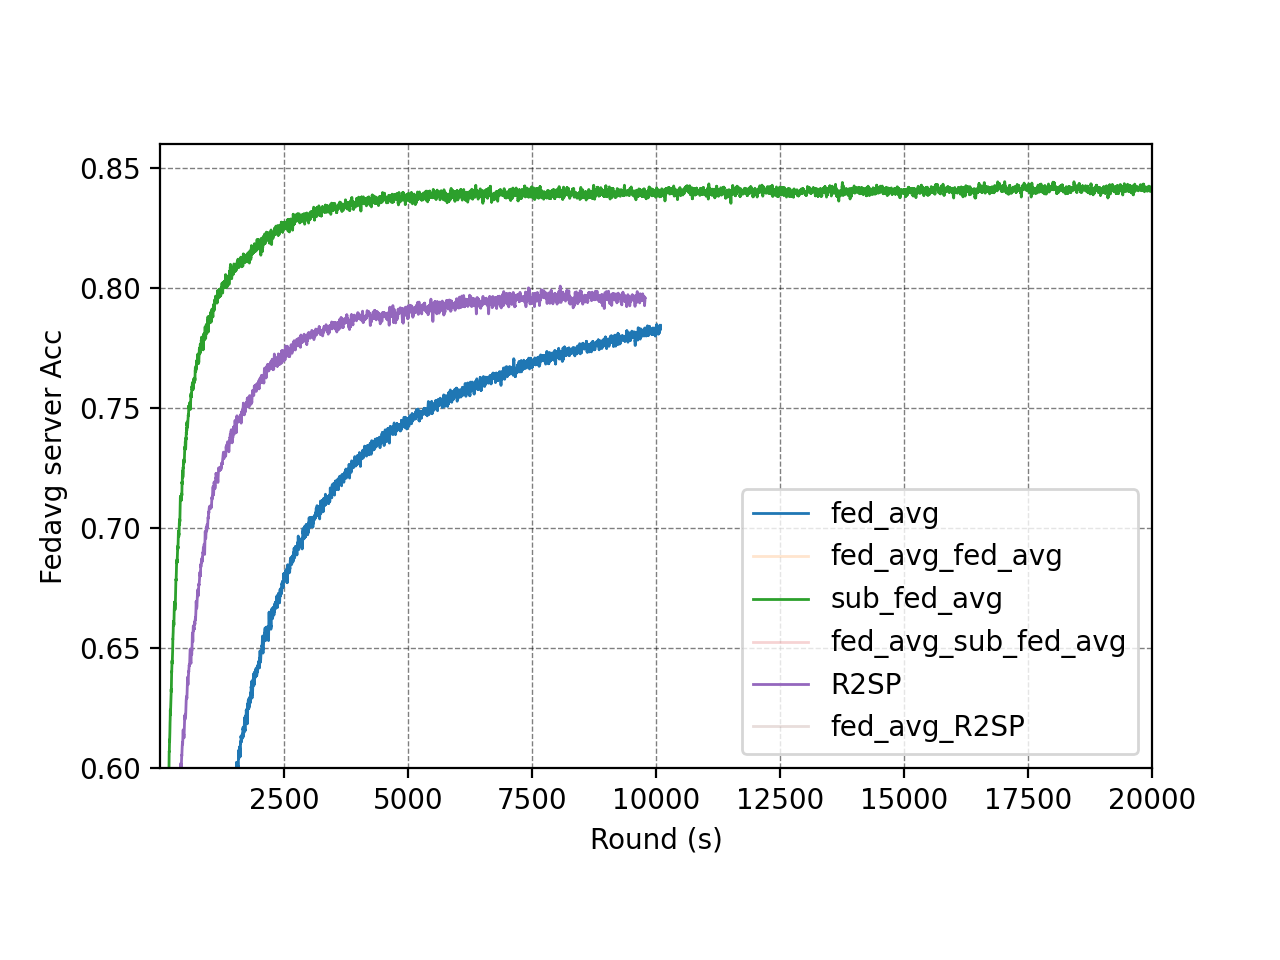

In [58]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


In [66]:
exp = [
     'Hetero_FL——[Hetero_fair_cuda20000_smalltobig]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_sub_fed_avg_g_0.0_0.1',
'Hetero_FL——[Hetero_fair_cuda20000_bigtosmall]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_sub_fed_avg_g_0.0_0.1']


exp_legend = ['1,1,1',
              '1,1,1',

]




<IPython.core.display.Javascript object>


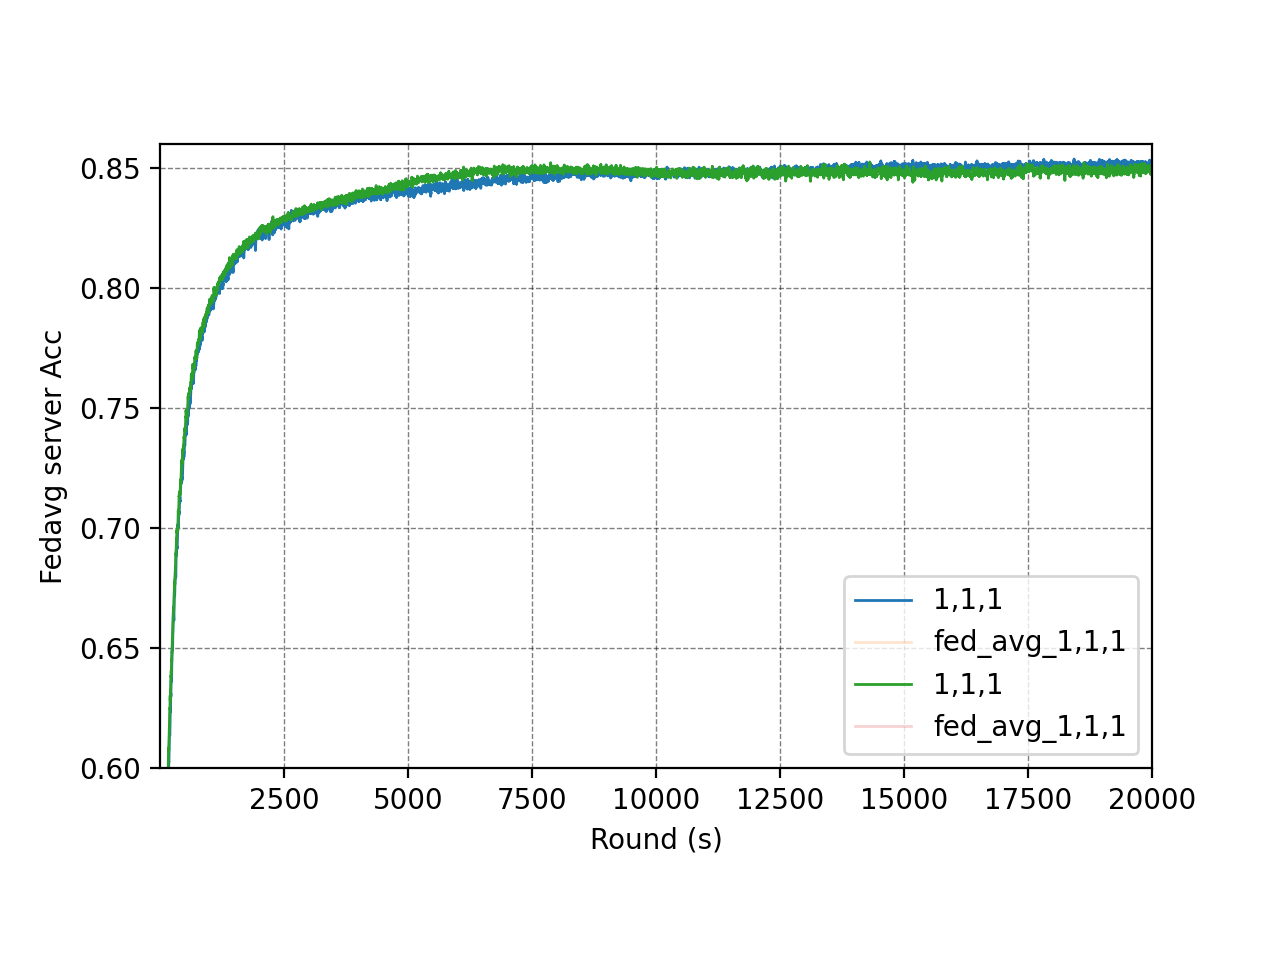

In [68]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


In [243]:
#to plot server acc

In [248]:
exp = ['Hetero_FL——[Hetero_fair_cuda_(1,5,1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg'
]


exp_legend = ['1,5,1',
]

In [262]:
# how do different densities affect the model acc
exp = [
    'Hetero_FL——[Hetero_fair_cuda_(1,5,9)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,93)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,96)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,98)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',

        'Hetero_FL——[Hetero_fair_cuda_(1,5,10)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,1,0.1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg', 
    'Hetero_FL——[Hetero_fair_cuda_(1,1,1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg'
]


exp_legend = [
              '1,5,9',
    '1,5,93','1,5,96','1,5,98',
    '1,5,10',
              '1,1,0.1',
              '1,1,1',
]

In [41]:
exp = [
#     'adaptive',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_1e-05_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.6]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_R2SP_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 1.0]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]n_-2.0_1_no_increase_-1.0_sub_fed_avg_g',
  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_fed_avg_w',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]u_1.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.4]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]u_-2.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.8]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]n_1.0_1_no_increase_-1.0_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg']


exp_legend = [
#     [1,1,1],
 '[1, 0.5, 0.1]1e-05',
 '[1, 0.5, 0.6]',
#  '[1, 0.5, 0.1]R2SP_g',
    '[1, 0.5, 0.2]',
    '[1, 0.5, 1.0]',
    '[1, 0.5, 0.1]n_-2.0',
     '[1, 0.5, 0.1]w',
    '[1, 0.5, 0.1]u_1.0',
#     '[1, 0.5, 0.4]',
    '[1, 0.5, 0.1]u_-2.0',
#     '[1, 0.5, 0.1]_fed_avg',
#     '[1, 0.5, 0.8]',
    '[1, 0.5, 0.1]n_1',
    '[1, 0.5, 0.1]'
    ]





In [10]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


<IPython.core.display.Javascript object>

Skipping training results for FEMNIST, PIF_FEMNIST2_[1.0, 0.6, 0.3, 0.1]0.08__recover_polybuff_mask_fed_avg_Resdiual_niid__n__50_____esc. Client selection = False.
Skipping training results for FEMNIST, PIF_FEMNIST2_[1.0, 0.6, 0.3, 0.1]0.08__asyn__recover_polyfed_avg_Resdiual_niid__n__50_____esc. Client selection = False.


<IPython.core.display.Javascript object>


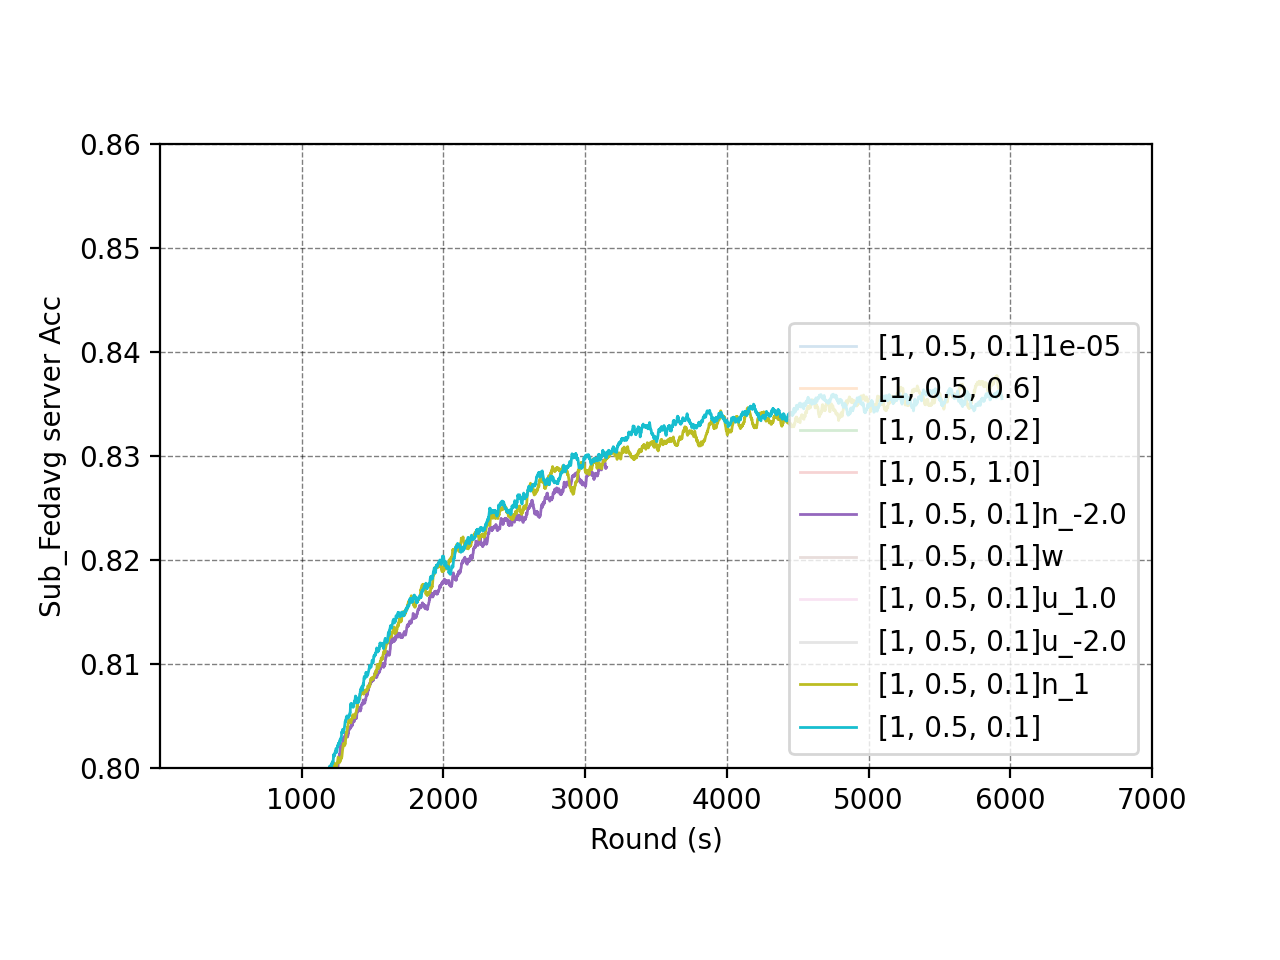

In [43]:
plt.figure()
n=50
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
#         avg_acc = load_fed_avg_acc(exp_name)
#         avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive_prune'or exp_name == 'adaptive_fine_tune':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
#         plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")

plt.xlabel(r"Round (s)")
plt.ylabel("Sub_Fedavg server Acc")
plt.xlim([1,7000])
plt.ylim([0.80,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)  # Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


<IPython.core.display.Javascript object>


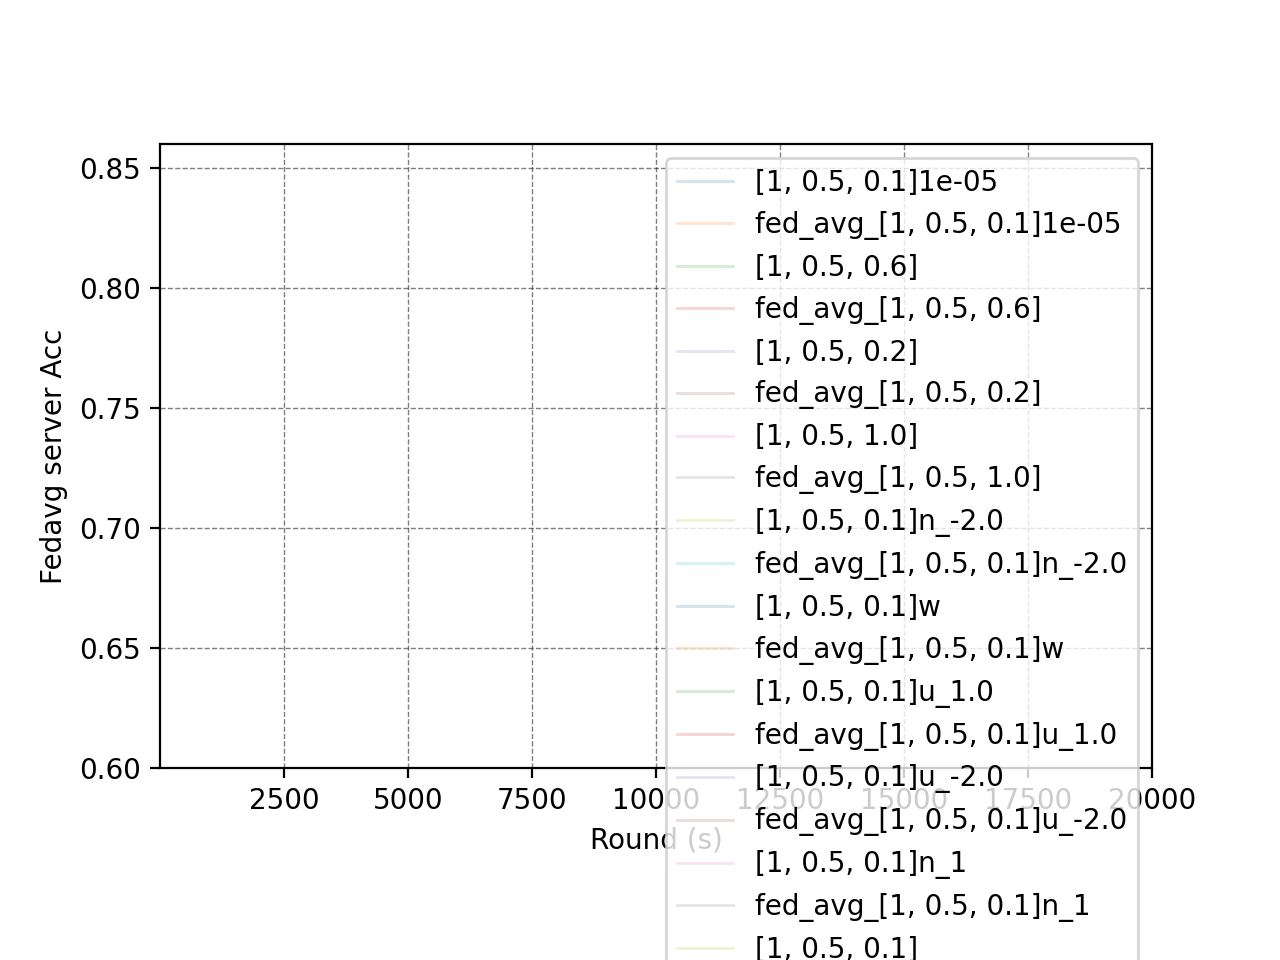

In [45]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()
